<img src="https://drive.google.com/uc?export=view&id=14reVO1X6LsjqJ3cFgoeHxxddZVGfZn3t" width="100%">

# Modelamiento
---

# Modelamiento

Este notebook desarrolla la fase de modelamiento del sistema de reconocimiento facial para un problema de clasificación multiclase con tres identidades. En esta etapa se implementan el particionamiento del conjunto de datos, la definición de una línea base, el entrenamiento de modelos basados en aprendizaje profundo, la búsqueda de hiperparámetros y la selección del modelo final.
   
El diseño metodológico incluye: (i) una estrategia de extracción de características mediante transferencia de aprendizaje, (ii) la comparación entre al menos dos enfoques de modelamiento, (iii) un reporte de línea base frente a un modelo de referencia básico y (iv) la justificación del modelo finalmente seleccionado para evaluación.

In [ ]:
!pip install -q keras_tuner gdown

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 4.9 MB/s eta 0:00:00


In [ ]:
import os
import zipfile
import shutil
from glob import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import keras_tuner as kt
import gdown

from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

In [ ]:
SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 3

ZIP_PATH = "/content/dataset_limpio.zip"
EXTRACT_DIR = "/content/extracted_dataset"
OUTPUT_DIR = "/content/output_modelamiento"

os.makedirs(EXTRACT_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

np.random.seed(SEED)
tf.random.set_seed(SEED)

## 1. Carga y validación del conjunto de datos

En esta sección se descarga, descomprime y valida el conjunto de imágenes previamente depurado. La validación inicial permite verificar que la estructura del dataset sea consistente con un problema de clasificación supervisada, es decir, que exista una carpeta por clase y que cada clase contenga imágenes utilizables para el entrenamiento del modelo.

Este paso es importante porque garantiza la trazabilidad de los datos desde el entorno de adquisición y preprocesamiento hacia la etapa de modelamiento. Además, permite confirmar que el conjunto final contiene tres clases y 315 imágenes, lo que define el alcance experimental del entrenamiento posterior.

In [ ]:
dataset_url = "https://drive.google.com/file/d/1jGgN6t9Me6SlNvE0xsoK6Lzlh1-0v6Fr/view?usp=drive_link"

gdown.download(dataset_url, ZIP_PATH, fuzzy=True, quiet=False)

size_mb = os.path.getsize(ZIP_PATH) / (1024**2)
print(f"Tamaño descargado: {size_mb:.2f} MB")

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Extracción completada.")

Downloading...
From: https://drive.google.com/uc?id=1jGgN6t9Me6SlNvE0xsoK6Lzlh1-0v6Fr
To: /content/dataset_limpio.zip
100%|██████████| 6.21M/6.21M [00:00<00:00, 41.9MB/s]


Tamaño descargado: 5.92 MB
Extracción completada.


In [ ]:
def find_dataset_root(base_dir, min_class_folders=2):
    candidates = []

    for root, dirs, files in os.walk(base_dir):
        subdirs = [d for d in dirs if not d.startswith(".") and d != "__MACOSX"]
        if len(subdirs) >= min_class_folders:
            valid_subdirs = 0
            for d in subdirs:
                class_path = os.path.join(root, d)
                images = glob(os.path.join(class_path, "*.jpg"))
                images += glob(os.path.join(class_path, "*.jpeg"))
                images += glob(os.path.join(class_path, "*.png"))
                if len(images) > 0:
                    valid_subdirs += 1
            if valid_subdirs >= min_class_folders:
                candidates.append(root)

    candidates = sorted(set(candidates), key=lambda x: len(x))
    return candidates[0] if candidates else None

DATA_DIR = find_dataset_root(EXTRACT_DIR)

if DATA_DIR is None:
    raise ValueError("No se encontró una carpeta válida de dataset con subcarpetas de clases e imágenes.")

print("Ruta raíz del dataset detectada:")
print(DATA_DIR)
print("Subcarpetas encontradas:", os.listdir(DATA_DIR))

Ruta raíz del dataset detectada:
/content/extracted_dataset/content/dataset_limpio
Subcarpetas encontradas: ['jose', 'juan', 'nicolas']


In [ ]:
for cls in sorted(os.listdir(DATA_DIR)):
    class_path = os.path.join(DATA_DIR, cls)
    if os.path.isdir(class_path):
        imgs = glob(os.path.join(class_path, "*.jpg"))
        imgs += glob(os.path.join(class_path, "*.jpeg"))
        imgs += glob(os.path.join(class_path, "*.png"))
        print(f"{cls}: {len(imgs)} imágenes")

jose: 121 imágenes
juan: 90 imágenes
nicolas: 104 imágenes


Aunque el problema es de visión por computador, se construye una representación tabular mínima del conjunto de datos mediante un `DataFrame` con las rutas de archivo y sus etiquetas de clase. Esta estructura facilita la partición estratificada, el uso de generadores de imágenes y la reproducibilidad del experimento.

Desde el punto de vista metodológico, esta organización separa claramente los insumos del modelo de la lógica de entrenamiento y reduce el riesgo de errores por manejo manual de rutas. También permite documentar con precisión cuántas observaciones tiene cada clase antes de iniciar el proceso de particionamiento.

In [ ]:
classes = sorted([
    d for d in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, d))
])

filepaths = []
labels = []

for cls in classes:
    class_path = os.path.join(DATA_DIR, cls)
    images = glob(os.path.join(class_path, "*.jpg"))
    images += glob(os.path.join(class_path, "*.jpeg"))
    images += glob(os.path.join(class_path, "*.png"))

    filepaths.extend(images)
    labels.extend([cls] * len(images))

metadata = pd.DataFrame({
    "filename": filepaths,
    "class": labels
})

print("Número total de imágenes:", len(metadata))
metadata.head()

Número total de imágenes: 315


,filename,class
0,/content/extracted_dataset/content/dataset_lim...,jose
1,/content/extracted_dataset/content/dataset_lim...,jose
2,/content/extracted_dataset/content/dataset_lim...,jose
3,/content/extracted_dataset/content/dataset_lim...,jose
4,/content/extracted_dataset/content/dataset_lim...,jose


## 2. Particionamiento del conjunto de datos

Se aplica una partición estratificada de 70% para entrenamiento, 15% para validación y 15% para prueba. La estratificación conserva la proporción de clases en cada subconjunto y reduce el riesgo de sesgo durante el aprendizaje y la evaluación del modelo.

La separación en entrenamiento, validación y prueba cumple una función metodológica distinta: el conjunto de entrenamiento se utiliza para ajustar los parámetros del modelo, el conjunto de validación se emplea para comparar configuraciones e hiperparámetros, y el conjunto de prueba se reserva para estimar el desempeño final sobre datos no vistos. Este diseño evita tomar decisiones de modelamiento usando directamente el conjunto de prueba, lo cual fortalece la validez del experimento.

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    metadata["filename"],
    metadata["class"],
    test_size=0.30,
    stratify=metadata["class"],
    random_state=SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=SEED
)

train_df = pd.DataFrame({"filename": X_train, "class": y_train}).reset_index(drop=True)
val_df   = pd.DataFrame({"filename": X_val,   "class": y_val}).reset_index(drop=True)
test_df  = pd.DataFrame({"filename": X_test,  "class": y_test}).reset_index(drop=True)

print("Entrenamiento:", train_df.shape[0])
print("Validación:", val_df.shape[0])
print("Prueba:", test_df.shape[0])

Entrenamiento: 220
Validación: 47
Prueba: 48


## Persistencia de las particiones

Las particiones generadas se almacenan en archivos CSV y se empaquetan en un archivo comprimido. Esta decisión permite desacoplar la fase de modelamiento de la fase de evaluación, ya que el mismo conjunto de entrenamiento, validación y prueba puede reutilizarse posteriormente sin recalcular la partición.

Además, esta práctica mejora la reproducibilidad del proyecto y facilita su integración con el repositorio versionado, dado que otros notebooks o scripts pueden consumir exactamente los mismos subconjuntos de datos.

In [ ]:
partitions_zip = os.path.join(OUTPUT_DIR, "particiones_dataset.zip")

with zipfile.ZipFile(partitions_zip, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    zf.writestr("train_df.csv", train_df.to_csv(index=False))
    zf.writestr("val_df.csv", val_df.to_csv(index=False))
    zf.writestr("test_df.csv", test_df.to_csv(index=False))

print("Particiones guardadas en:", partitions_zip)

Particiones guardadas en: /content/output_modelamiento/particiones_dataset.zip


## 3. Generadores de datos

En esta sección se construyen generadores de datos a partir de los `DataFrame` creados previamente. Para entrenamiento se aplican transformaciones de aumento de datos, mientras que para validación y prueba únicamente se utiliza el preprocesamiento compatible con la arquitectura EfficientNetB0. [file:154]

El uso de `data augmentation` introduce variabilidad controlada en las imágenes de entrenamiento, lo que contribuye a mejorar la capacidad de generalización del modelo. Por su parte, mantener validación y prueba sin aumentos aleatorios permite que las métricas obtenidas reflejen de forma más estable el rendimiento real del sistema sobre ejemplos no alterados artificialmente. [file:154]

In [ ]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.20,
    horizontal_flip=True
)

eval_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filename",
    y_col="class",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)

val_generator = eval_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="filename",
    y_col="class",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False,
    seed=SEED
)

test_generator = eval_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filename",
    y_col="class",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False,
    seed=SEED
)

CLASS_NAMES = list(train_generator.class_indices.keys())
print("Clases:", CLASS_NAMES)

Found 220 validated image filenames belonging to 3 classes.
Found 47 validated image filenames belonging to 3 classes.
Found 48 validated image filenames belonging to 3 classes.
Clases: ['jose', 'juan', 'nicolas']


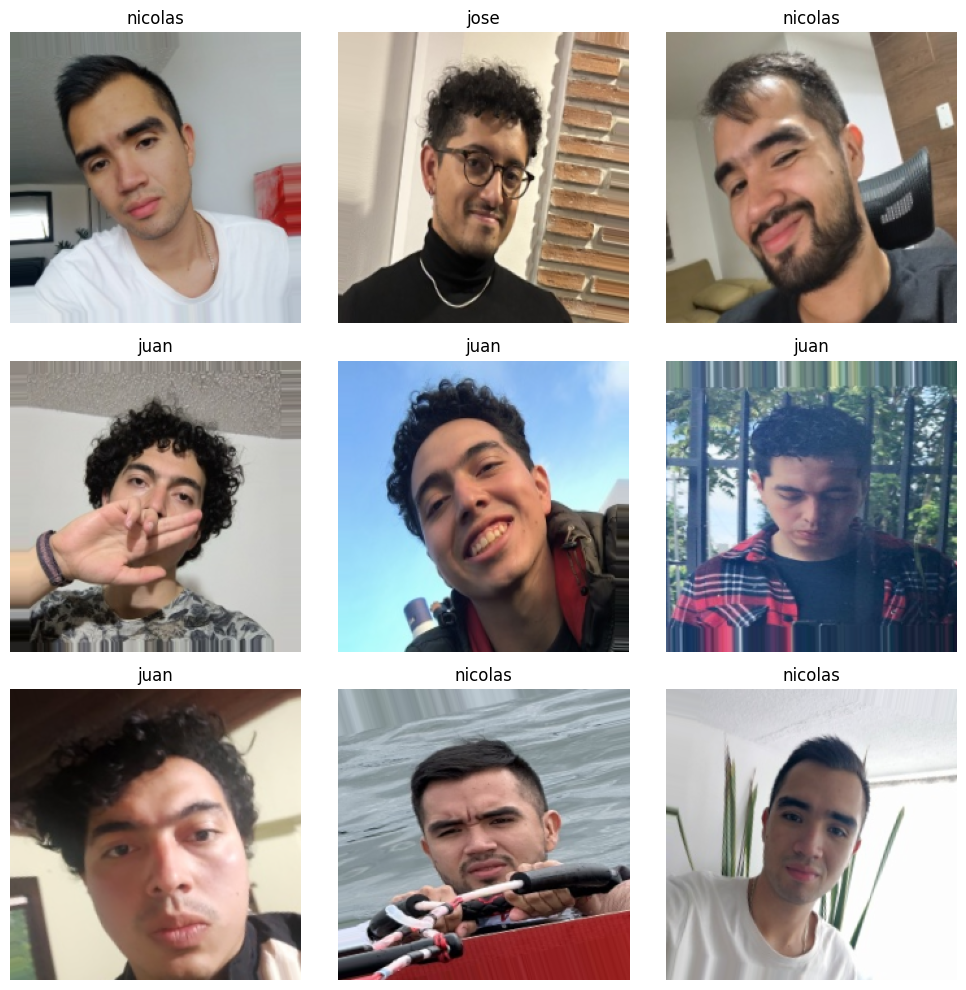

In [ ]:
images, labels_batch = next(train_generator)

plt.figure(figsize=(10, 10))
for i in range(min(9, len(images))):
    plt.subplot(3, 3, i + 1)
    img = (images[i] - images[i].min()) / (images[i].max() - images[i].min() + 1e-8)
    plt.imshow(img)
    plt.title(CLASS_NAMES[np.argmax(labels_batch[i])])
    plt.axis("off")
plt.tight_layout()
plt.show()

La principal técnica de extracción de características utilizada en este proyecto es la transferencia de aprendizaje con EfficientNetB0 preentrenada en ImageNet. En este enfoque, el backbone convolucional actúa como extractor automático de rasgos visuales de alto nivel, tales como contornos, texturas, patrones faciales y relaciones espaciales entre regiones de la imagen.


Esta estrategia es adecuada para el problema porque el conjunto de datos es relativamente pequeño y entrenar una red profunda desde cero incrementaría el riesgo de sobreajuste. Al reutilizar representaciones aprendidas previamente en un corpus amplio, el modelo parte de características visuales robustas y luego adapta la cabeza clasificadora a las tres clases específicas del proyecto.

## 4. Modelo de referencia
Como punto de comparación se define un modelo de referencia básico basado en una CNN pequeña entrenada desde cero. Su propósito no es maximizar el rendimiento, sino establecer una línea base mínima que permita cuantificar el valor agregado de la transferencia de aprendizaje frente a una arquitectura más simple y sin conocimiento previo.

Esta comparación es relevante para la rúbrica, ya que el reporte de línea base no debe limitarse a presentar un único modelo, sino mostrar de manera argumentada por qué una alternativa más avanzada resulta superior al enfoque básico de referencia. En este caso, la CNN base representa el escenario inicial contra el cual se contrasta el desempeño de EfficientNetB0.


El segundo enfoque de modelamiento corresponde a una arquitectura basada en EfficientNetB0 con pesos preentrenados en ImageNet, sin la capa superior original (`include_top=False`). Sobre este extractor se adicionan una capa de `GlobalAveragePooling2D`, una capa densa completamente conectada, regularización mediante `Dropout` y una capa de salida `softmax` ajustada al número de clases del problema.

Esta configuración combina extracción de características profundas con una cabeza clasificadora ligera, lo que permite adaptar el modelo al dominio específico sin reentrenar toda la red desde el inicio. En términos metodológicos, este enfoque constituye una segunda técnica de modelamiento claramente diferenciada del modelo de referencia, cumpliendo así el requisito de comparar al menos dos modelos.

In [ ]:
def build_transfer_model(hp):
    keras.backend.clear_session()

    base_model = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base_model.trainable = False

    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(
        units=hp.Choice("units", [128, 256, 512]),
        activation="relu"
    )(x)
    x = layers.Dropout(
        rate=hp.Choice("dropout", [0.2, 0.3, 0.4])
    )(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = keras.Model(inputs, outputs)

    lr = hp.Float("lr", min_value=1e-5, max_value=1e-3, sampling="log")

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
tuner = kt.RandomSearch(
    hypermodel=build_transfer_model,
    objective="val_loss",
    max_trials=5,
    executions_per_trial=1,
    overwrite=True,
    directory=os.path.join(OUTPUT_DIR, "tuner"),
    project_name="efficientnet_transfer"
)

tuner.search_space_summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Search space summary
Default search space size: 3
units (Choice)
{'default': 128, 'conditions': [], 'values': [128, 256, 512], 'ordered': True}
dropout (Choice)
{'default': 0.2, 'conditions': [], 'values': [0.2, 0.3, 0.4], 'ordered': True}
lr (Float)
{'default': 1e-05, 'conditions': [], 'min_value': 1e-05, 'max_value': 0.001, 'step': None, 'sampling': 'log'}


## 5. Búsqueda de hiperparámetros

Una vez definida la arquitectura de transferencia de aprendizaje, se realiza una búsqueda de hiperparámetros con `Keras Tuner` usando `RandomSearch`. El espacio de búsqueda incluye el número de unidades de la capa densa, la tasa de `Dropout` y la tasa de aprendizaje del optimizador Adam.

La finalidad de esta etapa es ajustar de manera sistemática la capacidad del clasificador y la dinámica de optimización, en lugar de fijar estos valores de forma arbitraria. De acuerdo con los resultados obtenidos, la mejor combinación encontrada fue `units = 128`, `dropout = 0.2` y `learning rate = 0.000796...`, lo cual fundamenta la configuración empleada para el entrenamiento principal del modelo de transferencia.

In [ ]:
early_stop_tuner = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

reduce_lr_tuner = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

tuner.search(
    train_generator,
    validation_data=val_generator,
    epochs=12,
    callbacks=[early_stop_tuner, reduce_lr_tuner],
    verbose=1
)

Trial 5 Complete [00h 01m 32s]
val_loss: 0.8431529402732849

Best val_loss So Far: 0.3027203679084778
Total elapsed time: 00h 07m 43s


In [ ]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

print("Mejores hiperparámetros:")
print("units:", best_hp.get("units"))
print("dropout:", best_hp.get("dropout"))
print("lr:", best_hp.get("lr"))

Mejores hiperparámetros:
units: 128
dropout: 0.2
lr: 0.0007962196754828313


In [ ]:
transfer_model = tuner.hypermodel.build(best_hp)
transfer_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,926 (16.07 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
best_transfer_path = os.path.join(OUTPUT_DIR, "best_transfer_efficientnet.keras")
final_transfer_path = os.path.join(OUTPUT_DIR, "final_transfer_efficientnet.keras")

checkpoint_transfer = ModelCheckpoint(
    filepath=best_transfer_path,
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop_transfer = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr_transfer = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

## 6. Entrenamiento del mejor modelo de transferencia

Con los mejores hiperparámetros se entrena el modelo de transferencia de aprendizaje utilizando el conjunto de entrenamiento y monitoreando el desempeño sobre validación. Para estabilizar el proceso se emplean `ModelCheckpoint`, `EarlyStopping` y `ReduceLROnPlateau`, que permiten conservar la mejor versión del modelo, detener el entrenamiento cuando deja de mejorar y ajustar dinámicamente la tasa de aprendizaje.

Los resultados de esta fase muestran un mejor `val_accuracy` de 0.829787 y un mejor `val_loss` de 0.364165. Estos valores constituyen una primera referencia sólida del desempeño del enfoque basado en extracción automática de características con EfficientNetB0.

In [ ]:
history_transfer = transfer_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[checkpoint_transfer, early_stop_transfer, reduce_lr_transfer],
    verbose=1
)

Epoch 1/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4130 - loss: 1.1136
Epoch 1: val_accuracy improved from None to 0.63830, saving model to /content/output_modelamiento/best_transfer_efficientnet.keras

Epoch 1: finished saving model to /content/output_modelamiento/best_transfer_efficientnet.keras
7/7 ━━━━━━━━━━━━━━━━━━━━ 47s 4s/step - accuracy: 0.4909 - loss: 0.9861 - val_accuracy: 0.6383 - val_loss: 0.8045 - learning_rate: 7.9622e-04
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 500ms/step - accuracy: 0.7982 - loss: 0.5824
Epoch 2: val_accuracy improved from 0.63830 to 0.74468, saving model to /content/output_modelamiento/best_transfer_efficientnet.keras

Epoch 2: finished saving model to /content/output_modelamiento/best_transfer_efficientnet.keras
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 656ms/step - accuracy: 0.8409 - loss: 0.5332 - val_accuracy: 0.7447 - val_loss: 0.6591 - learning_rate: 7.9622e-04
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - accuracy: 0.8943 - loss: 0.3727
Epoch 3:

In [ ]:
transfer_model.save(final_transfer_path)

history_transfer_df = pd.DataFrame(history_transfer.history)
history_transfer_csv = os.path.join(OUTPUT_DIR, "history_transfer_learning.csv")
history_transfer_df.to_csv(history_transfer_csv, index=False)

print("Mejor modelo transfer learning:", best_transfer_path)
print("Modelo final transfer learning:", final_transfer_path)
print("Historial transfer learning:", history_transfer_csv)

Mejor modelo transfer learning: /content/output_modelamiento/best_transfer_efficientnet.keras
Modelo final transfer learning: /content/output_modelamiento/final_transfer_efficientnet.keras
Historial transfer learning: /content/output_modelamiento/history_transfer_learning.csv


## 7. Fine tuning del backbone

Tras entrenar la cabeza clasificadora, se implementa una fase de `fine tuning` mediante el descongelamiento parcial de las últimas capas del backbone EfficientNetB0. Esta estrategia permite reajustar representaciones profundas ya aprendidas para especializarlas aún más en el dominio del reconocimiento facial planteado en el proyecto.

En términos de extracción de características, esta fase complementa la etapa anterior: primero se reutilizan características generales preentrenadas y luego se refinan selectivamente las capas más cercanas a la salida. De este modo, el proyecto no solo usa transferencia de aprendizaje como mecanismo de extracción, sino también ajuste fino como estrategia de especialización del extractor para el problema concreto.

In [ ]:
fine_tune_model = tf.keras.models.load_model(best_transfer_path)
fine_tune_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,542,638 (17.33 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

 Optimizer params: 328,712 (1.25 MB)

In [ ]:
base_model = None

for layer in fine_tune_model.layers:
    if isinstance(layer, tf.keras.Model) and "efficientnet" in layer.name.lower():
        base_model = layer
        break

if base_model is None:
    raise ValueError("No se encontró el backbone EfficientNet dentro del modelo.")

base_model.trainable = True

fine_tune_at = len(base_model.layers) - 60

#se descongelan las últimas 60 capas del BackBone

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

for layer in base_model.layers[fine_tune_at:]:
    layer.trainable = True

print("Backbone encontrado:", base_model.name)
print("Capas totales backbone:", len(base_model.layers))
print("Capas descongeladas desde:", fine_tune_at)

Backbone encontrado: efficientnetb0
Capas totales backbone: 238
Capas descongeladas desde: 178


In [ ]:
fine_tune_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
print("Modelo recompilado correctamente.")

print("\nBackbone:", base_model.name)
print("Total capas backbone:", len(base_model.layers))

trainable_backbone_layers = [layer.name for layer in base_model.layers if layer.trainable]
non_trainable_backbone_layers = [layer.name for layer in base_model.layers if not layer.trainable]

print("Capas entrenables en backbone:", len(trainable_backbone_layers))
print("Capas congeladas en backbone:", len(non_trainable_backbone_layers))

print("\nÚltimas capas entrenables del backbone:")
for name in trainable_backbone_layers[-10:]:
    print(name)

Modelo recompilado correctamente.

Backbone: efficientnetb0
Total capas backbone: 238
Capas entrenables en backbone: 60
Capas congeladas en backbone: 178

Últimas capas entrenables del backbone:
block7a_se_squeeze
block7a_se_reshape
block7a_se_reduce
block7a_se_expand
block7a_se_excite
block7a_project_conv
block7a_project_bn
top_conv
top_bn
top_activation


In [ ]:
trainable_count = np.sum([layer.trainable for layer in fine_tune_model.layers])
print("Número de capas entrenables en el modelo final:", trainable_count)

Número de capas entrenables en el modelo final: 6


In [ ]:
best_finetune_path = os.path.join(OUTPUT_DIR, "best_finetuned_efficientnet.keras")
final_finetune_path = os.path.join(OUTPUT_DIR, "final_finetuned_efficientnet.keras")

checkpoint_finetune = ModelCheckpoint(
    filepath=best_finetune_path,
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop_finetune = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_lr_finetune = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=1,
    min_lr=1e-7,
    verbose=1
)

In [ ]:
history_finetune = fine_tune_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=6,
    callbacks=[checkpoint_finetune, early_stop_finetune, reduce_lr_finetune],
    verbose=1
)

Epoch 1/6
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8636 - loss: 0.5074
Epoch 1: val_accuracy improved from None to 0.85106, saving model to /content/output_modelamiento/best_finetuned_efficientnet.keras

Epoch 1: finished saving model to /content/output_modelamiento/best_finetuned_efficientnet.keras
7/7 ━━━━━━━━━━━━━━━━━━━━ 67s 5s/step - accuracy: 0.8500 - loss: 0.5230 - val_accuracy: 0.8511 - val_loss: 0.4814 - learning_rate: 1.0000e-05
Epoch 2/6
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step - accuracy: 0.8543 - loss: 0.5351
Epoch 2: val_accuracy did not improve from 0.85106
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 410ms/step - accuracy: 0.8727 - loss: 0.5070 - val_accuracy: 0.8511 - val_loss: 0.4690 - learning_rate: 1.0000e-05
Epoch 3/6
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step - accuracy: 0.8415 - loss: 0.4871
Epoch 3: val_accuracy did not improve from 0.85106
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 524ms/step - accuracy: 0.8455 - loss: 0.4857 - val_accuracy: 0.8511 - val_loss: 0.4564 - learning_rate: 1.0000

In [ ]:
fine_tune_model.save(final_finetune_path)

history_finetune_df = pd.DataFrame(history_finetune.history)
history_finetune_csv = os.path.join(OUTPUT_DIR, "history_fine_tuning.csv")
history_finetune_df.to_csv(history_finetune_csv, index=False)

print("Mejor modelo fine tuning:", best_finetune_path)
print("Modelo final fine tuning:", final_finetune_path)
print("Historial fine tuning:", history_finetune_csv)

Mejor modelo fine tuning: /content/output_modelamiento/best_finetuned_efficientnet.keras
Modelo final fine tuning: /content/output_modelamiento/final_finetuned_efficientnet.keras
Historial fine tuning: /content/output_modelamiento/history_fine_tuning.csv


## 8. Comparación entre transferencia de aprendizaje y fine tuning

Para comparar las configuraciones entrenadas se construye un resumen con las mejores métricas de validación por fase. El modelo de transferencia de aprendizaje alcanzó `best_val_accuracy = 0.829787` y `best_val_loss = 0.364165`, mientras que el modelo ajustado con fine tuning alcanzó `best_val_accuracy = 0.893617` y `best_val_loss = 0.428463`.

Estos resultados muestran que el fine tuning incrementó la exactitud de validación respecto al modelo de transferencia inicial, aunque con una pérdida de validación ligeramente mayor. Por ello, la selección final del modelo se fundamenta principalmente en el criterio de desempeño predictivo observado en validación, complementado después con la verificación sobre el conjunto de prueba en el notebook de evaluación.

In [ ]:
summary_rows = []

best_transfer_val_acc = max(history_transfer.history["val_accuracy"])
best_transfer_val_loss = min(history_transfer.history["val_loss"])

best_finetune_val_acc = max(history_finetune.history["val_accuracy"])
best_finetune_val_loss = min(history_finetune.history["val_loss"])

summary_rows.append({
    "fase": "transfer_learning",
    "best_val_accuracy": best_transfer_val_acc,
    "best_val_loss": best_transfer_val_loss
})

summary_rows.append({
    "fase": "fine_tuning",
    "best_val_accuracy": best_finetune_val_acc,
    "best_val_loss": best_finetune_val_loss
})

summary_df = pd.DataFrame(summary_rows)
summary_csv = os.path.join(OUTPUT_DIR, "resumen_modelamiento.csv")
summary_df.to_csv(summary_csv, index=False)

summary_df

,fase,best_val_accuracy,best_val_loss
0,transfer_learning,0.829787,0.364165
1,fine_tuning,0.893617,0.428463


In [ ]:
if best_finetune_val_acc >= best_transfer_val_acc:
    selected_model_path = best_finetune_path
    selected_stage = "fine_tuning"
else:
    selected_model_path = best_transfer_path
    selected_stage = "transfer_learning"

print("Modelo seleccionado:", selected_stage)
print("Ruta del modelo seleccionado:", selected_model_path)

Modelo seleccionado: fine_tuning
Ruta del modelo seleccionado: /content/output_modelamiento/best_finetuned_efficientnet.keras


## 9. Selección del modelo final

La selección del modelo final se realiza comparando el mejor desempeño en validación entre las alternativas entrenadas. Bajo este criterio, el notebook selecciona la versión obtenida mediante fine tuning, ya que presenta la mayor exactitud de validación entre las fases comparadas.

Esta decisión queda documentada mediante la exportación del archivo `modelofinalseleccionado.keras`, lo que permite desacoplar la etapa de entrenamiento de la etapa de evaluación. Así, el modelo elegido no solo queda justificado experimentalmente, sino también preparado para su trazabilidad y posterior puesta en producción.

In [ ]:
selected_export_path = os.path.join(OUTPUT_DIR, "modelo_final_seleccionado.keras")
shutil.copy(selected_model_path, selected_export_path)

print("Modelo final exportado en:", selected_export_path)

Modelo final exportado en: /content/output_modelamiento/modelo_final_seleccionado.keras


In [ ]:
with open(os.path.join(OUTPUT_DIR, "selected_model_path.txt"), "w") as f:
    f.write(selected_export_path)

print("Archivo de referencia creado.")

Archivo de referencia creado.


In [ ]:
from google.colab import files

files.download(best_transfer_path)
files.download(final_transfer_path)
files.download(best_finetune_path)
files.download(final_finetune_path)
files.download(selected_export_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download(partitions_zip)
files.download(history_transfer_csv)
files.download(history_finetune_csv)
files.download(summary_csv)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Créditos
---
* **Profesores:**
  - [Jorge E. Camargo, PhD](https://dis.unal.edu.co/~jecamargom/)
* **Asistentes docentes:**
    - [Juan Sebastián Malagón Torres](https://co.linkedin.com/in/juan-sebastian-malag%C3%B3n-torres-86039a164).
* **Diseño de imágenes:**
    - [Sebastián Daniel Moreno Martinez](http://www.linkedin.com/in/sm-xwx).
* **Coordinador de virtualización:**
    - [Edder Hernández Forero](https://www.linkedin.com/in/edder-hernandez-forero-28aa8b207/).
    